# Exploratory Data Analysis -- Telco Customer Churn

FR-4. Explores the cleaned dataset (`data/processed/customers_clean.csv`, 7,043 rows)
to understand churn distributions, revenue patterns, and segment-level risk --
cross-checked against the actual numbers from Phase 3's SQL analytics
(`reports/phase3_findings.md`) so the Python and SQL sides of this project agree.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/customers_clean.csv")
df.shape

(7043, 21)

In [2]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,True


## 1. Churn Distribution

What fraction of customers have churned overall?

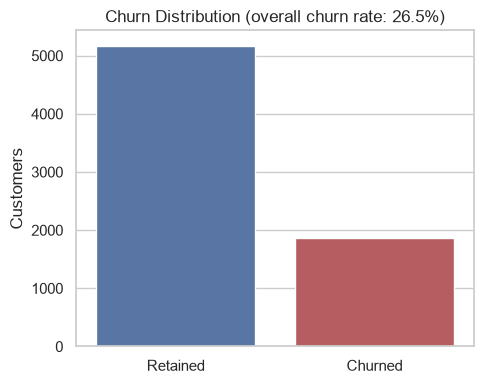

churn
False    5174
True     1869
Name: count, dtype: int64

In [3]:
churn_counts = df["churn"].value_counts()
churn_rate = 100 * churn_counts[True] / len(df)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="churn", hue="churn", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"])
ax.set_title(f"Churn Distribution (overall churn rate: {churn_rate:.1f}%)")
ax.set_xlabel("")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

churn_counts

**Interpretation:** 26.5% of the 7,043 customers have churned -- matches Phase 3's
`total_customers`/`churn_rate_pct` query exactly (1,869 churned, 26.54%). This is a
meaningfully imbalanced target (roughly 3:1 retained:churned), which is why Phase 5's
model training will need class weighting rather than treating this as a balanced
classification problem.

## 2. Monthly Charges Distribution

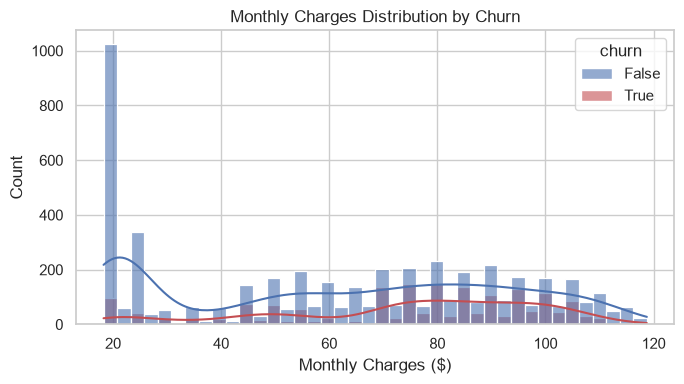

,mean,50%,std
churn,,,
False,61.265124,64.425,31.092648
True,74.441332,79.650,24.666053


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="monthly_charges", hue="churn", bins=40, kde=True,
             palette=["#4C72B0", "#C44E52"], alpha=0.6, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn")
ax.set_xlabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

df.groupby("churn")["monthly_charges"].describe()[["mean", "50%", "std"]]

**Interpretation:** Churned customers skew toward higher monthly charges -- their
distribution is shifted right compared to retained customers. Phase 3's quartile
analysis showed churn *peaking* in the third quartile ($70.35-$89.85, 37.4% churn)
rather than the top quartile (32.8%), which this chart's shape confirms: risk rises
with price but tapers slightly at the very top, plausibly because the highest spenders
are also disproportionately on long, autopay contracts.

## 3. Tenure Distribution

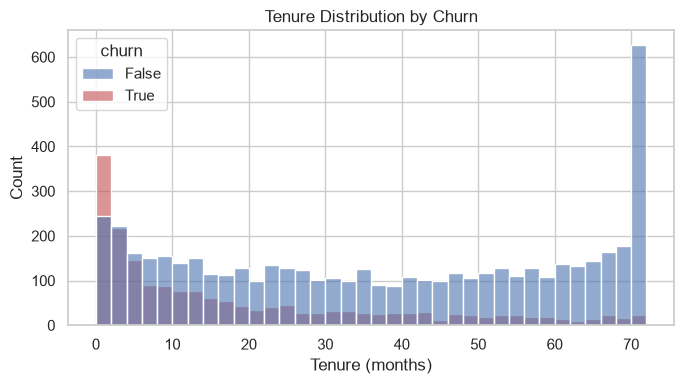

churn
False    37.569965
True     17.979133
Name: tenure_months, dtype: float64

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="tenure_months", hue="churn", bins=36,
             palette=["#4C72B0", "#C44E52"], alpha=0.6, ax=ax)
ax.set_title("Tenure Distribution by Churn")
ax.set_xlabel("Tenure (months)")
plt.tight_layout()
plt.show()

df.groupby("churn")["tenure_months"].mean()

**Interpretation:** Churned customers are heavily concentrated in the first few
months of tenure, while retained customers are spread much more evenly across the
full range. Average tenure is 18.0 months for churned vs. 37.6 months for retained --
identical to Phase 3's finding. Combined with the tenure-bucket query (47.4% churn in
months 0-12, down to 9.5% at 49+ months), the first year is clearly the highest-risk
window and where retention effort matters most.

## 4. Correlation Heatmap

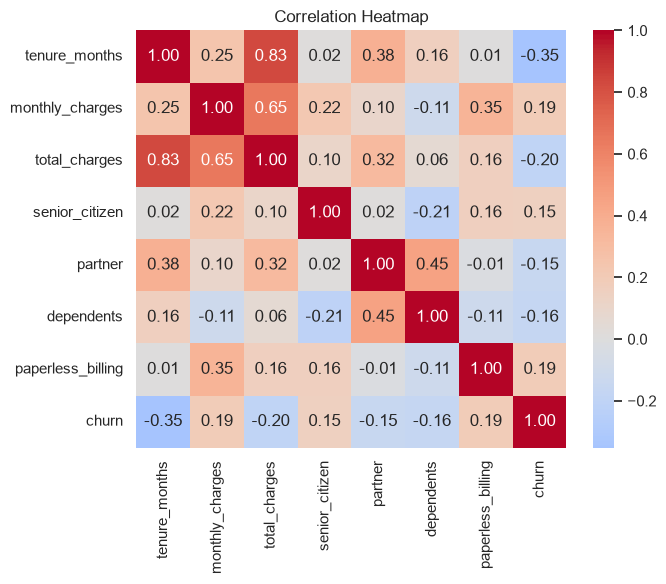

In [6]:
numeric_df = df.copy()
numeric_df["churn"] = numeric_df["churn"].astype(int)
numeric_df["senior_citizen"] = numeric_df["senior_citizen"].astype(int)
numeric_df["partner"] = numeric_df["partner"].astype(int)
numeric_df["dependents"] = numeric_df["dependents"].astype(int)
numeric_df["paperless_billing"] = numeric_df["paperless_billing"].astype(int)

corr_cols = ["tenure_months", "monthly_charges", "total_charges", "senior_citizen",
             "partner", "dependents", "paperless_billing", "churn"]
corr = numeric_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Interpretation:** `tenure_months` has the strongest correlation with churn among
these features (negative -- longer tenure, less churn), followed by `paperless_billing`
and `senior_citizen` (both positive). `monthly_charges` and `total_charges` are
strongly correlated with each other (expected, since total is roughly monthly x
tenure), which is a multicollinearity note worth carrying into Phase 5 feature
selection rather than a churn insight on its own.

## 5. Contract Type Breakdown

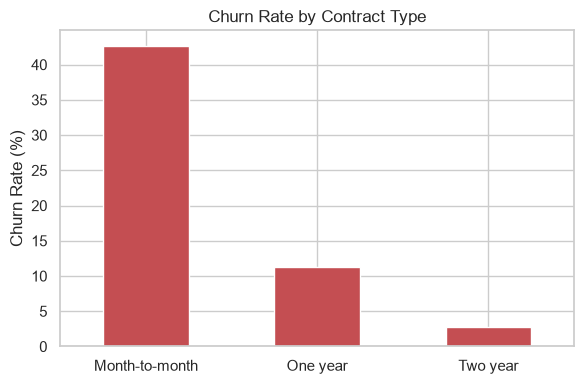

contract_type
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn, dtype: float64

In [7]:
contract_churn = df.groupby("contract_type", observed=True)["churn"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

contract_churn

**Interpretation:** Matches Phase 3 exactly -- Month-to-month churns at 42.71%,
One year at 11.27%, Two year at 2.83%. Contract length is the single strongest
categorical driver of churn in this dataset.

## 6. Payment Method Breakdown

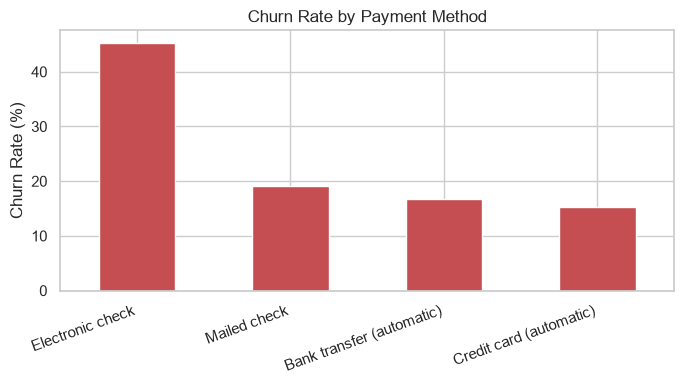

payment_method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: churn, dtype: float64

In [8]:
payment_churn = df.groupby("payment_method", observed=True)["churn"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
payment_churn.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

payment_churn

**Interpretation:** Electronic check payers churn at 45.29%, roughly 3x the rate of
either autopay method (Bank transfer 16.71%, Credit card 15.24%). Combined with contract
type, this is exactly the segment behind Phase 3's headline finding: month-to-month +
electronic check customers churn at 53.73% vs. 5.74% for annual-contract + autopay
customers.

## 7. Internet Service Breakdown

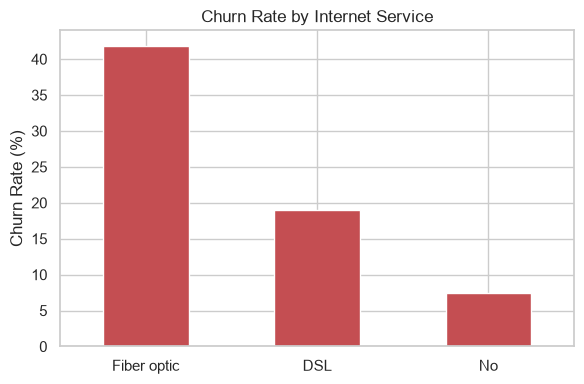

internet_service
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: churn, dtype: float64

In [9]:
internet_churn = df.groupby("internet_service", observed=True)["churn"].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
internet_churn.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_title("Churn Rate by Internet Service")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

internet_churn

**Interpretation:** Fiber optic customers churn at 41.89%, more than double DSL
(18.96%) despite -- or perhaps because of -- being the highest-priced tier (avg
$91.50/mo vs. $58.10 for DSL, per Phase 3). This suggests fiber's higher price point
isn't being matched by proportionally higher satisfaction, a candidate hypothesis for
why add-on services (Section 8) matter so much for this segment specifically.

## 8. Boxplots: Numerical Features vs. Churn

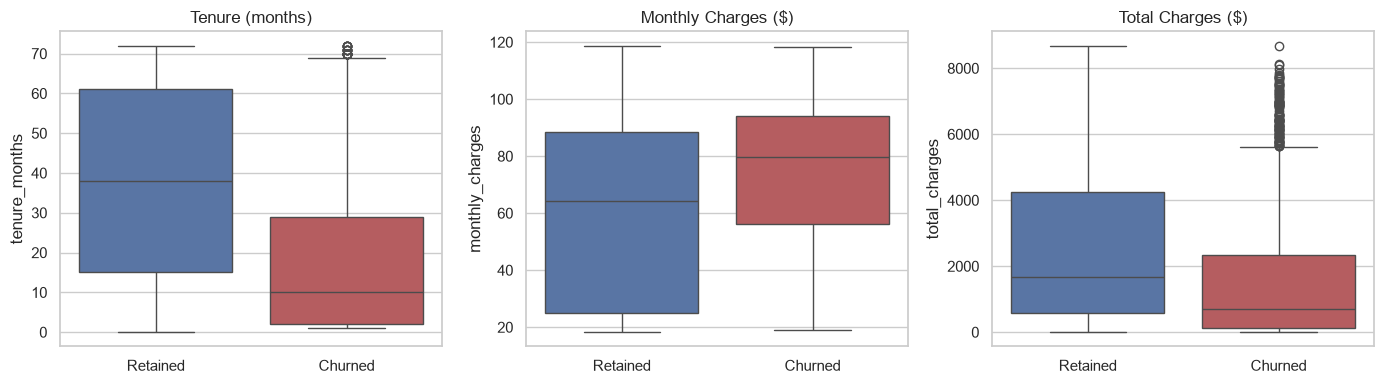

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ["tenure_months", "monthly_charges", "total_charges"],
    ["Tenure (months)", "Monthly Charges ($)", "Total Charges ($)"],
):
    sns.boxplot(data=df, x="churn", y=col, hue="churn", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_title(title)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

**Interpretation:** Churned customers show a lower median tenure and lower median
total charges (consistent with churning early, before charges accumulate) but a
*higher* median monthly charge -- reinforcing that churn here is driven by
price-sensitivity early in the relationship, not by long-term customers with high
cumulative spend leaving.

## Summary

The clearest churn drivers in this dataset, in order of apparent strength:

1. **Contract type** -- month-to-month vs. annual is the single biggest lever (42.71%
   vs. 2.83-11.27%).
2. **Tenure** -- risk is front-loaded into the first 12 months (47.4% churn) and drops
   steadily thereafter.
3. **Payment method** -- electronic check payers churn 3x more than autopay customers.
4. **Internet service tier** -- fiber optic customers churn more than double DSL,
   despite paying more.
5. **Add-on services** (online security, tech support, etc.) roughly halve churn when
   present, for customers who have internet service at all.

These findings directly motivate the engineered features in `feature_engineering.py`
(Tenure Group, Service Count, AutoPay Customer) and will carry into Phase 6's Business
Decision Engine, where the highest-risk, highest-value segments identified here become
the ones worth spending a retention offer on.